# Imports

In [1]:
import os
import sys
import time
import cv2
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
import matplotlib as mpl
from pathlib import Path
from pathml.preprocessing import TissueDetectionHE, LabelWhiteSpaceHE, LabelArtifactTileHE
from pathml.core import HESlide

sys.path.append('/mnt/scripts/biliseq_he_class2')
from helpers import anno as annoHelper
%load_ext autoreload
%autoreload 2

# use_model = 'densenet169_10fold_1rep_1000bal_224px'
use_model = 'densenet169_1fold_1rep_10933bal_224px'
method = 'slide'

svs_path = Path('/mnt/data/biliseq_he_class/raw/new_data_20220829')
tiles_path = Path('/mnt/results/v8/tiles/224px')
infer_path = Path('/mnt/results/v8/models/').joinpath(use_model).joinpath('infer_csv')
sampleinfo = Path('/mnt/sampleinfo')
dswsi_path = Path('/mnt/results/v8/ds/')
dswsi_path.mkdir(parents=True,exist_ok=True)
heatmap_path = Path('/mnt/results/v8/heatmaps/').joinpath(use_model)
heatmap_path.mkdir(parents=True,exist_ok=True)
slide_df = pd.read_csv(sampleinfo.joinpath('slide_df_v8.0_44.tsv'),sep='\t').drop(columns=['Unnamed: 0'])
tile_df = pd.read_csv(sampleinfo.joinpath('tile_df_v8.0_255347.tsv'),sep='\t').drop(columns=['Unnamed: 0'])  
print('Finished')
svs_path.exists()

/opt/conda/envs/py38/lib/python3.8/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Finished


True

# Define heatmap colormap & save colorbar

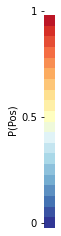

In [2]:
class MplColorHelper:

  def __init__(self, cmap_name, start_val, stop_val):
    self.cmap_name = cmap_name
    self.cmap = plt.get_cmap(cmap_name)
    self.norm = mpl.colors.Normalize(vmin=start_val, vmax=stop_val)
    self.scalarMap = cm.ScalarMappable(norm=self.norm, cmap=self.cmap)

  def get_rgb(self, val):
    return self.scalarMap.to_rgba(val)

#Generate colorbar:
w=2
cmap = 'RdYlBu'
COL = MplColorHelper(cmap, 0, 1)
val=np.arange(0,1,0.05)
im = np.zeros((len(val),w,3))
bar=[]
for i,v in enumerate(val):
    rgb = np.array(COL.get_rgb(1-v)[0:-1]) * 255
    # rgb = rgb.reshape((1,1,3))
    bar.append(rgb)
fig= plt.figure()
ax = fig.add_subplot()
plt.imshow(np.array(bar).reshape(len(val),1,3).astype('uint8'))
plt.xlabel('')
plt.yticks([0,len(val)/2,len(val)])
ax.set_yticklabels([0,0.5,1])
ax.set_xticklabels('')
ax.invert_yaxis()
plt.ylabel('P(Pos)')
for a in 'xy':
    plt.tick_params(
        axis=a,          # changes apply to the x-axis
        which='both',      # both major and minor ticks are affected
        bottom=False,      # ticks along the bottom edge are off
        top=False,         # ticks along the top edge are off
        labelbottom=False)
plt.box(False)
# fn = ds_path.joinpath('colorbar.eps')
fns=[heatmap_path.joinpath('colorbar.eps'),
     heatmap_path.joinpath('colorbar.png')]
for fn in fns:
    plt.savefig(fn)

# Generate downsampled image of WSIs excluding blank regions

In [2]:
# make downsampled .png images from each WSI:
def ds_img_from_wsi(wsi_fn,nchunks, ds,verbose = False):
    blank_detect=LabelWhiteSpaceHE(label_name='blank',
                                   proportion_threshold=0.99,
                                   )
    art_detect = LabelArtifactTileHE(label_name='artifact')
    wsi = HESlide(str(wsi_fn))
    x,y= wsi.shape
    tile_size= y // nchunks
    tot_tiles = (x//tile_size) * (y//tile_size)
    print(x,y,tile_size,tot_tiles)
    print('original slide shape:',x,y)
    dsx= x//ds
    dsy= y//ds
    print("ds shape:",dsx,dsy)
    print('tile size:', tile_size, 'total tiles:', tot_tiles)
    blank_image = np.zeros((dsx,dsy,3), np.uint8) +255
    blank_tot=0
    img_tot=0
    for i,tile in enumerate(wsi.generate_tiles(shape=tile_size,pad=False)):
        blank_detect.apply(tile)
        if tile.labels['blank'] == False:
            if verbose:
                print('Loading tile %d' % i)
            im =np.array(tile.image)
            img_tot+=1
            xx, yy = tile.coords
            imds= cv2.resize(im,
                             (tile_size//ds,tile_size//ds),
                              interpolation=cv2.INTER_CUBIC)
            dsxx= xx//ds
            dsyy= yy//ds

            blank_image[dsxx:(dsxx + imds.shape[1]),dsyy:(dsyy+imds.shape[0])]=imds
        else:
            blank_tot += 1
            if verbose:
                print('Tile %d detected as blank... skipping' % i)
    print('%d images loaded, %d detected as blank' % (img_tot,blank_tot))
    return blank_image

#Run on all:
nchunks=50
ds = 10
outpath = dswsi_path.joinpath('%dx' % ds)
outpath.mkdir(parents=True,exist_ok=True)
u_slides = slide_df.slide.unique()
for base_file in slide_df.loc[:,'accession_number'].values:
    if 'PHS16-15556' in base_file:
        print('skip PHS16-15556 it is corrupt.')
    else:    
        save_fn = outpath.joinpath('%s_full_ds%dx_min.png' % (base_file, ds))
        if save_fn.exists() == False:
            wsi_fn = svs_path.joinpath('%s.svs' % base_file)
            print("processing:", save_fn)
            ds_svs = ds_img_from_wsi(wsi_fn,nchunks,ds)
            ds_svs = cv2.cvtColor(ds_svs,cv2.COLOR_RGB2BGR)
            save_fn = outpath.joinpath('%s_full_ds%dx_min.png' % (base_file, ds))
            print('Save %s\n' % save_fn)
            cv2.imwrite(str(save_fn),ds_svs)
        else:
            print(save_fn, 'Already exists.. skipping.')

print('Finished All')

/mnt/results/v8/ds/10x/PHS15-7377 - 1007831_full_ds10x_min.png Already exists.. skipping.
/mnt/results/v8/ds/10x/PHS15-7510 - 1010330_full_ds10x_min.png Already exists.. skipping.
/mnt/results/v8/ds/10x/PHS15-9836 - 1007828_full_ds10x_min.png Already exists.. skipping.
/mnt/results/v8/ds/10x/PHS15-29884 - 1010333_full_ds10x_min.png Already exists.. skipping.
/mnt/results/v8/ds/10x/PHS16-5752 - 1010328_full_ds10x_min.png Already exists.. skipping.
skip PHS16-15556 it is corrupt.
/mnt/results/v8/ds/10x/PHS16-19238 - 1007825_full_ds10x_min.png Already exists.. skipping.
processing: /mnt/results/v8/ds/10x/PHS16-29893 - 1007826_full_ds10x_min.png
33094 115536 2310 700
original slide shape: 33094 115536
ds shape: 3309 11553
tile size: 2310 total tiles: 700
39 images loaded, 661 detected as blank
Save /mnt/results/v8/ds/10x/PHS16-29893 - 1007826_full_ds10x_min.png

processing: /mnt/results/v8/ds/10x/PHS16-30091 - 1007827_full_ds10x_min.png
16928 119520 2390 350
original slide shape: 16928 119

Finish that off with: slide-by-slide tile aggregatation similar to that used below

# Sanity check that tile file name (x,y) are correct in validation csv

Fold: 1
original slide shape: 21088 105576
ds shape: 2108 10557
0.0%
68.9%


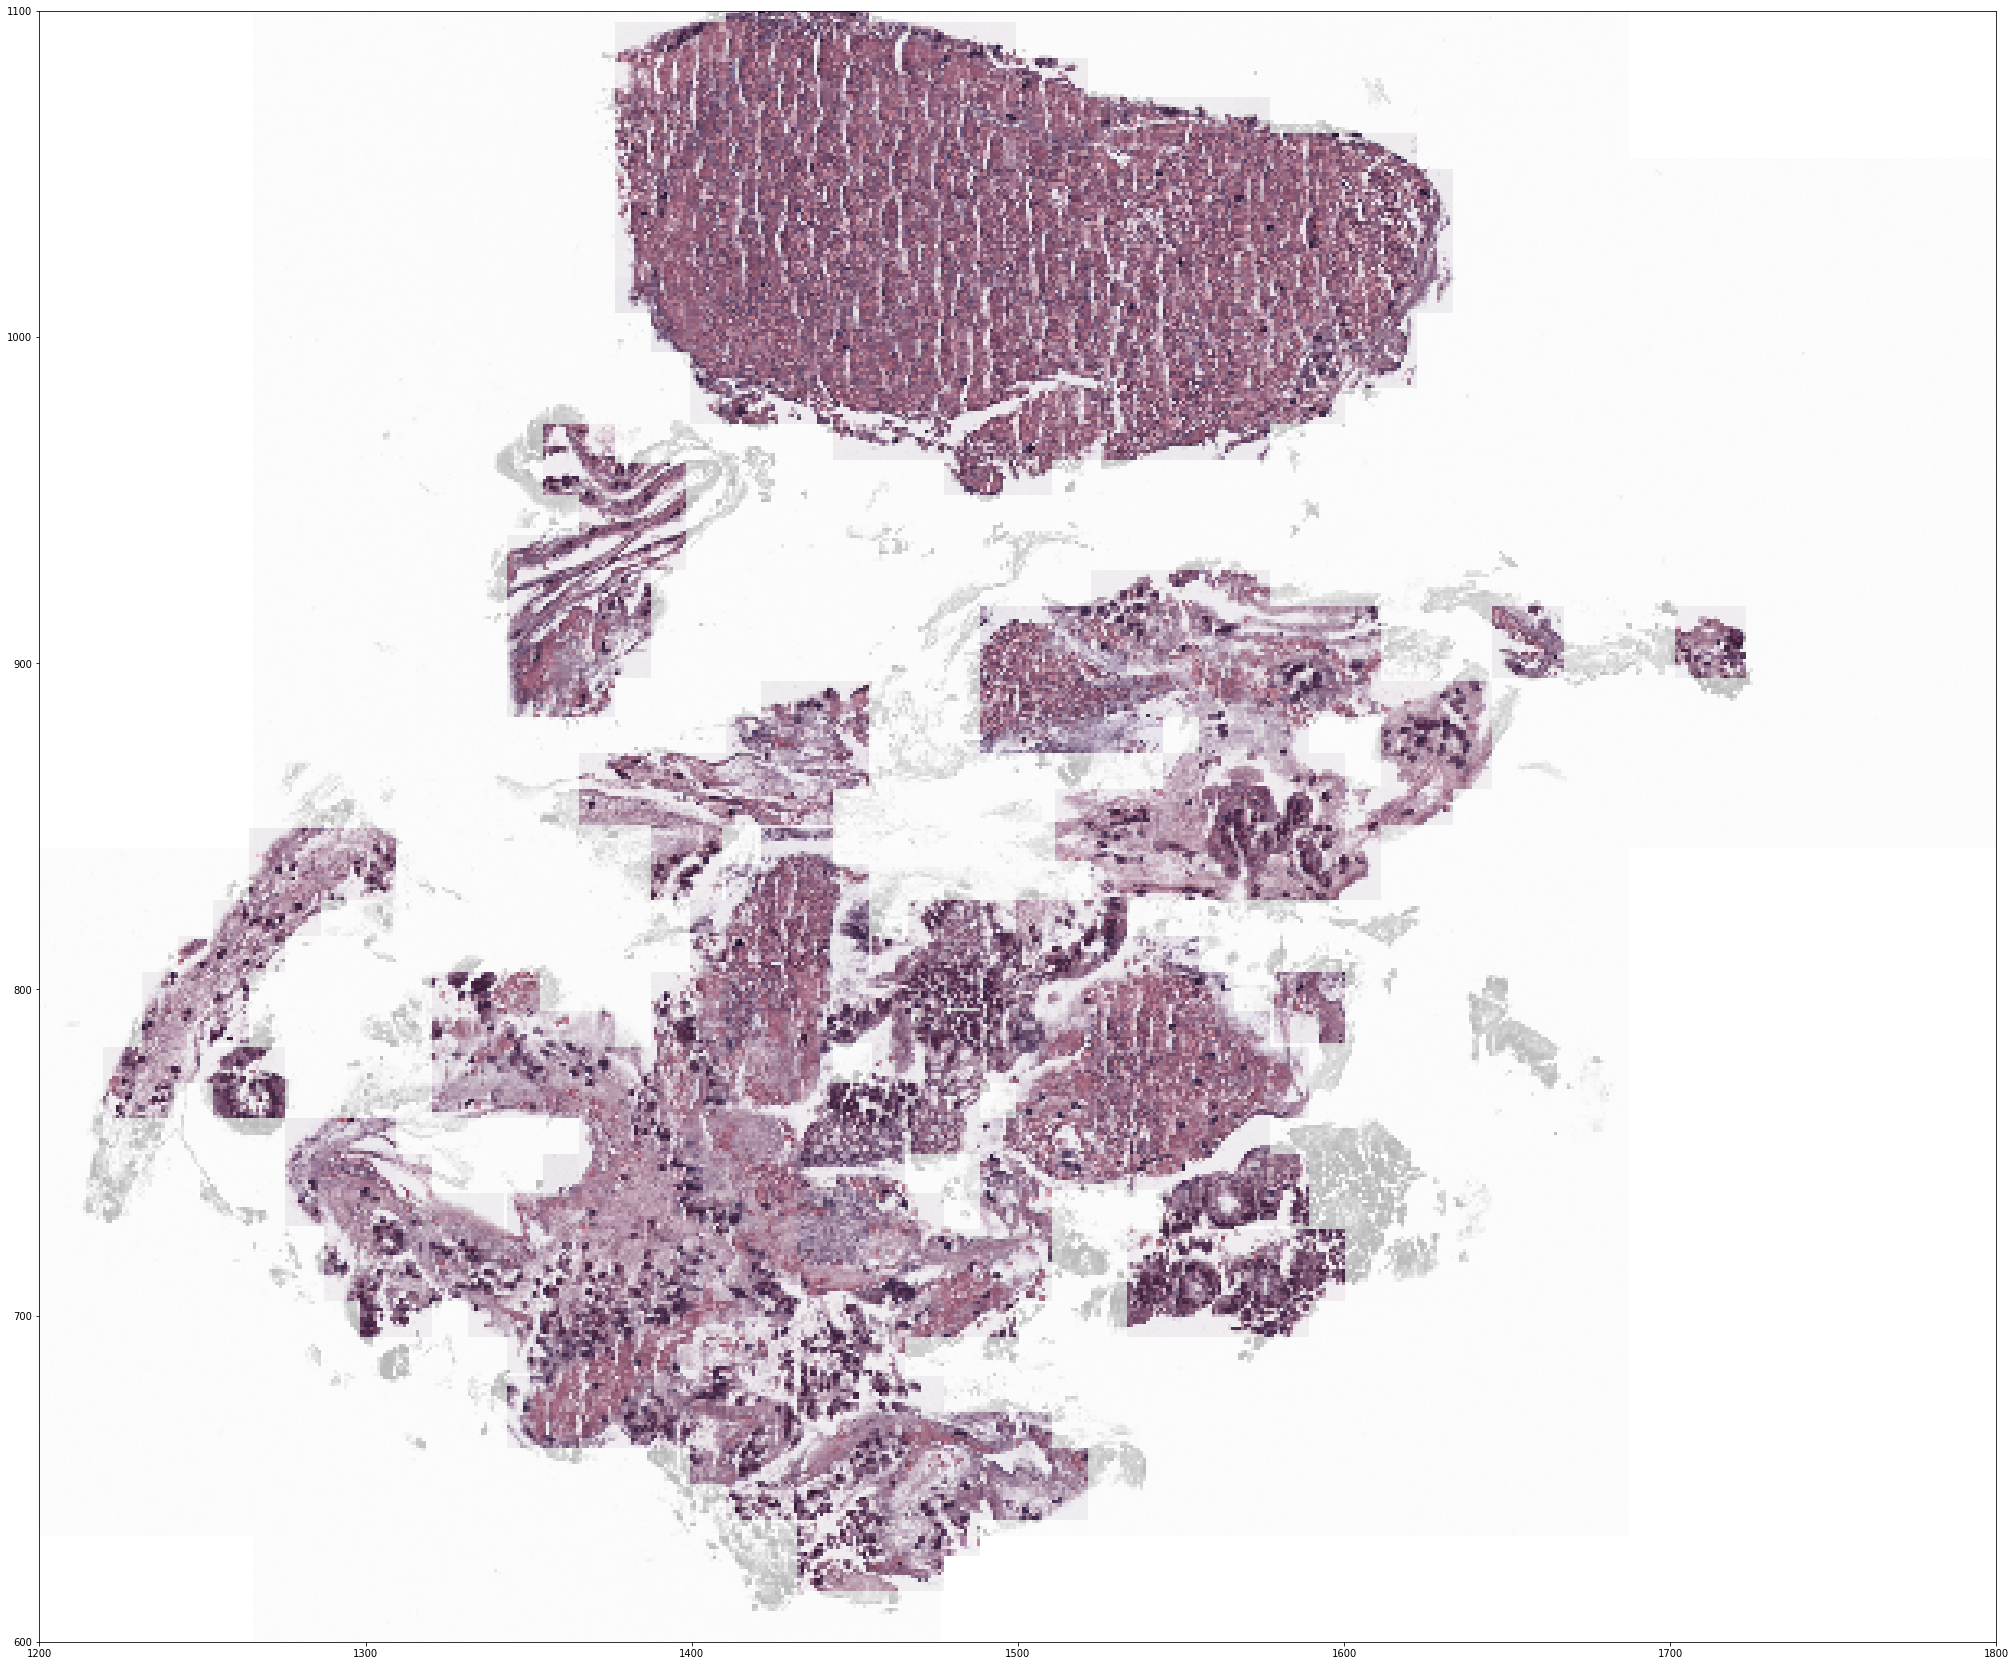

In [30]:
ds = 10
fold = 1
fn = infer_path.joinpath('fold_%d_all_valid_pred.csv' % fold)
df=pd.read_csv(fn)
u_slide = df.slide.unique()
slide = u_slide[0]
idx = slide_df.slide.values == slide
base_file = slide_df.loc[idx,'accession_number'].values[0]
dswsi = Path('/mnt/results/v8/ds/%dx' % ds)
bkg_fn = dswsi.joinpath('%s_full_ds%dx_min.png' % (base_file, ds))
bkg = cv2.imread(str(bkg_fn))
bkg = cv2.cvtColor(cv2.cvtColor(bkg,cv2.COLOR_RGB2GRAY),cv2.COLOR_GRAY2RGB)
if bkg_fn.exists():
    wsi = HESlide(str(svs_path.joinpath('%s.svs' % base_file)))
    x,y= wsi.shape
    xds= x//ds
    yds= y//ds
    print('Fold:', fold)
    print('original slide shape:',x,y)
    print("ds shape:",xds,yds)
    slide_idx = df.slide.values == slide
    tile_fns = df.loc[slide_idx,'cur_path'].values
    temp_img = np.zeros((xds,yds,3), np.uint8) +255
    for i,fn in enumerate(tile_fns):
        if (i % 1000) == 0:
            print('%2.1f%%' % (i/len(tile_fns)*100))
        tn,tx,ty,tile_size= annoHelper.parse_tile_fn(fn)
        im =  cv2.cvtColor(cv2.imread(fn),cv2.COLOR_BGR2RGB)
        ds_ts = tile_size//ds 
        dsx=tx//ds
        dsy=ty//ds
        imds = cv2.resize(im,(tile_size//ds,tile_size//ds),interpolation=cv2.INTER_CUBIC)
        temp_img[dsx:(dsx + imds.shape[1]),dsy:(dsy+imds.shape[0])]=imds
fig = plt.figure(figsize=(50,30))
ax = fig.add_subplot(1,1,1)
comb = cv2.addWeighted(bkg,0.3,temp_img,0.7, 0)
ax.imshow(comb)
ax.set_xlim([1200,1800]);
ax.set_ylim([600,1100]);

# Perform same examination with heatmap:

Fold: 1
original slide shape: 21088 105576
ds shape: 2108 10557
0.0%
68.9%


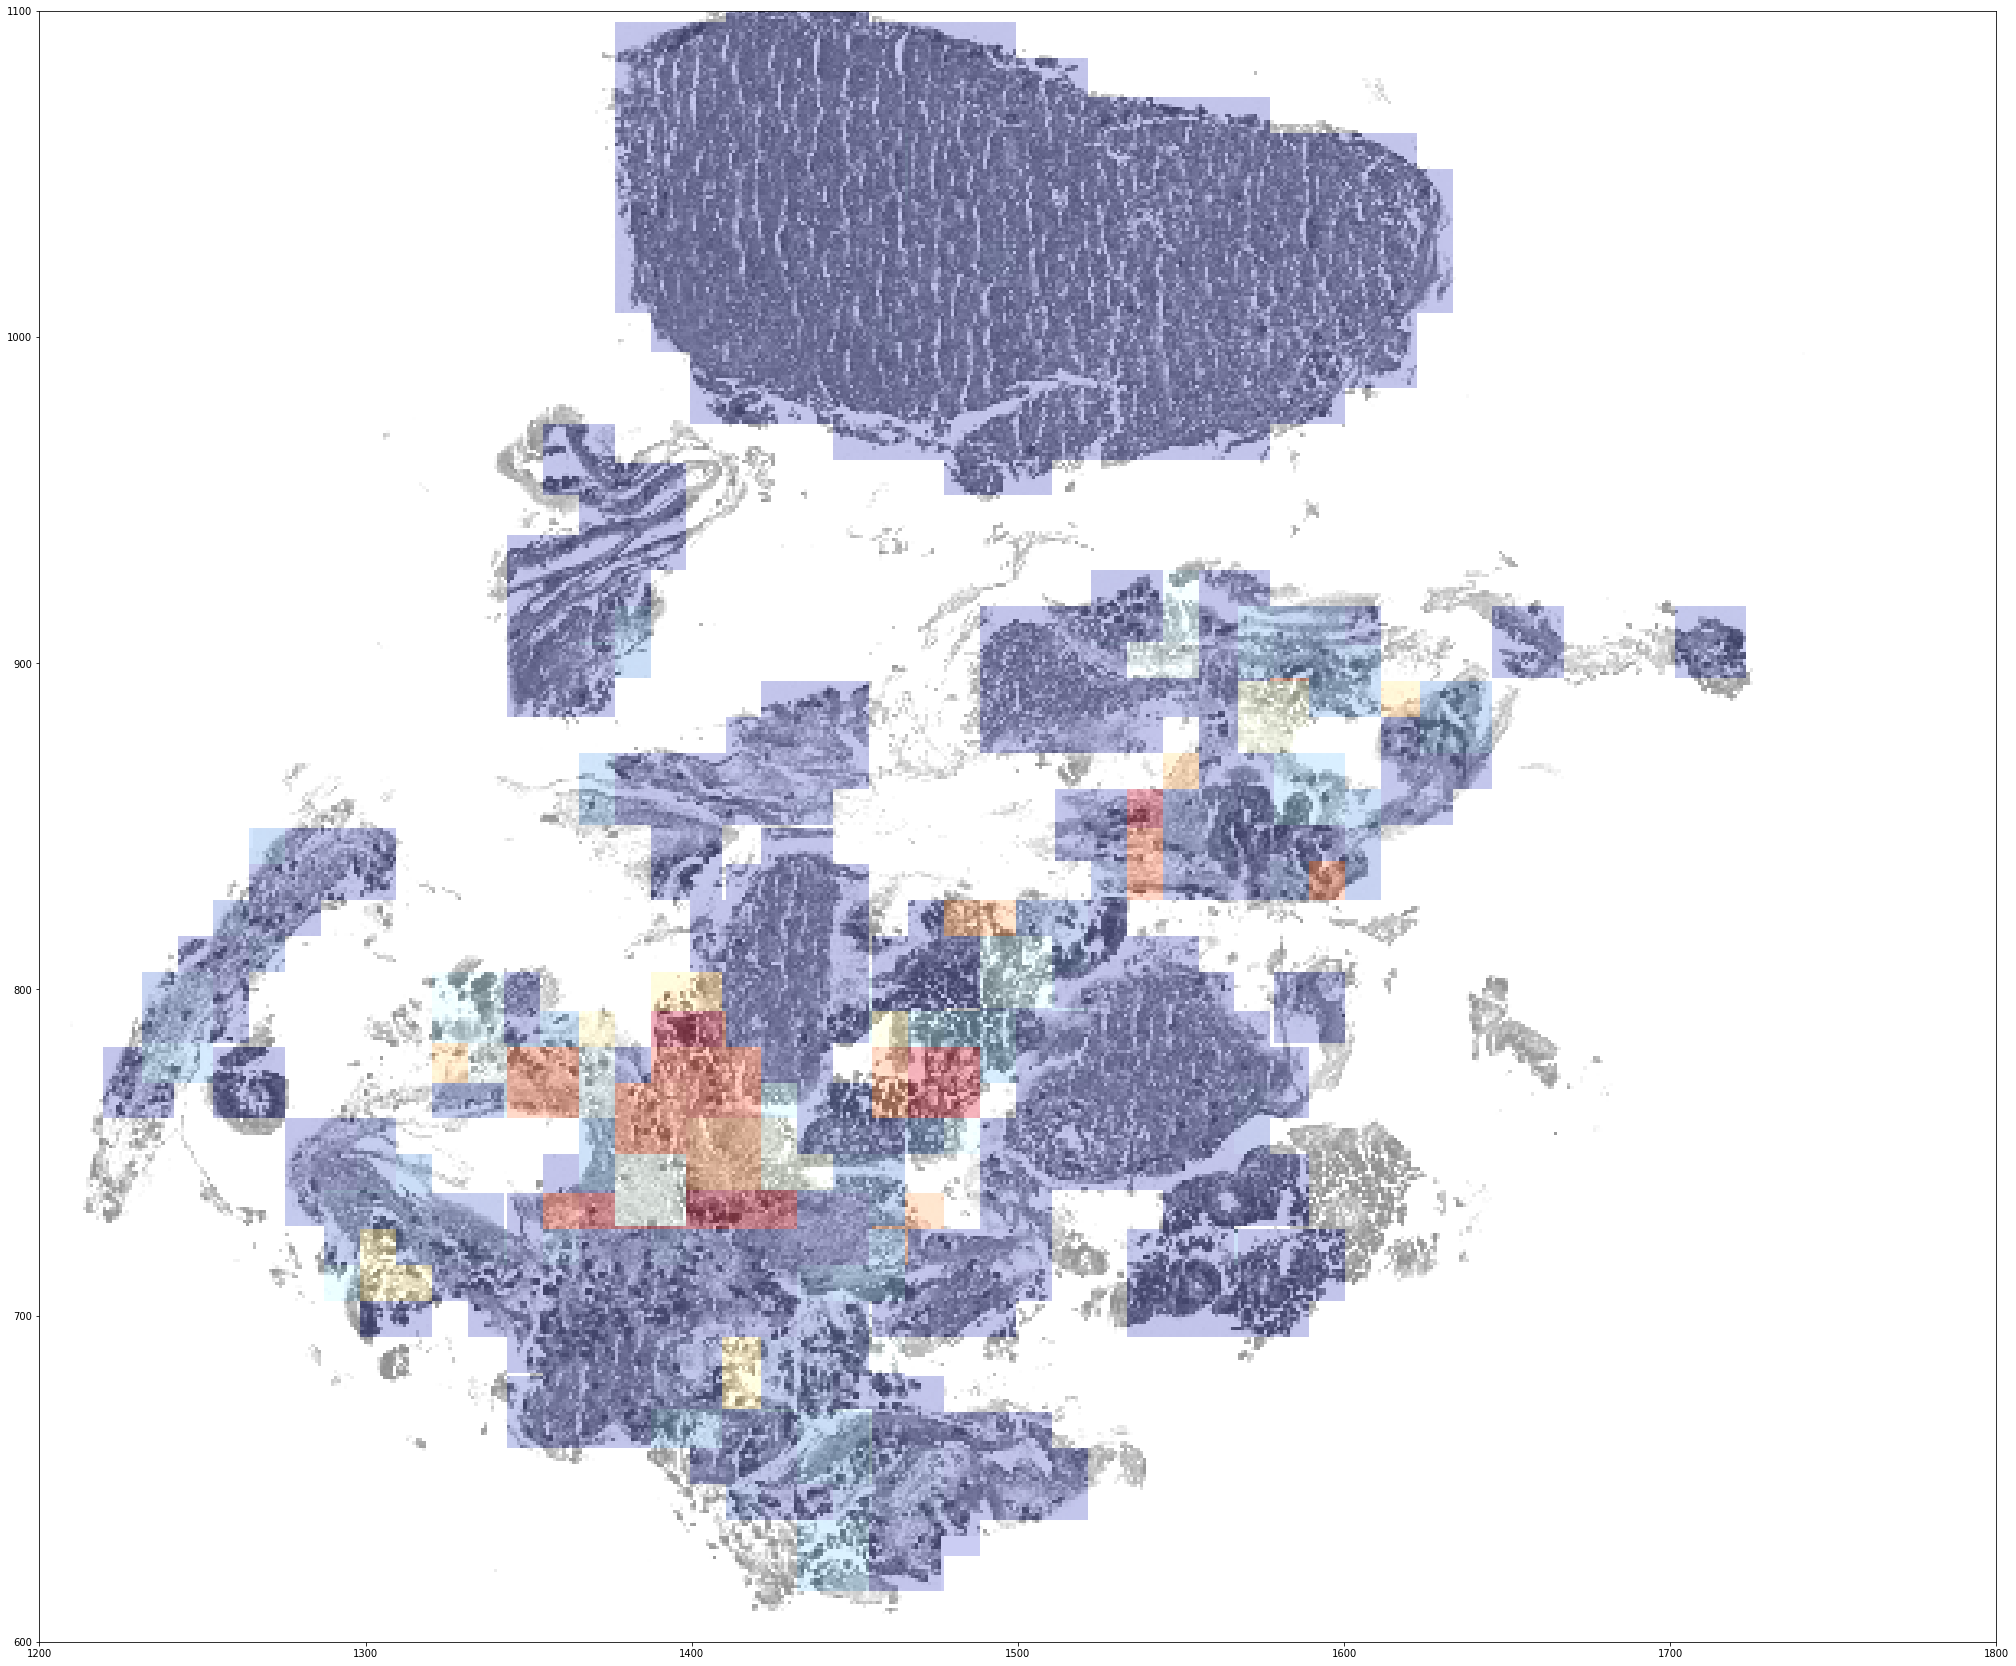

In [41]:
cmap = 'RdYlBu'
COL = MplColorHelper(cmap, 0, 1)
ds = 10
fold = 1
cls_types=['benign','malignant']
thresh = 0.16
fn = infer_path.joinpath('fold_%d_all_valid_pred.csv' % fold)
df=pd.read_csv(fn)
u_slide = df.slide.unique()
slide = u_slide[0]
idx = slide_df.slide.values == slide
base_file = slide_df.loc[idx,'accession_number'].values[0]
dswsi = Path('/mnt/results/v8/ds/%dx' % ds)
bkg_fn = dswsi.joinpath('%s_full_ds%dx_min.png' % (base_file, ds))
bkg = cv2.imread(str(bkg_fn))
bkg = cv2.cvtColor(cv2.cvtColor(bkg,cv2.COLOR_RGB2GRAY),cv2.COLOR_GRAY2RGB)
if bkg_fn.exists():
    wsi = HESlide(str(svs_path.joinpath('%s.svs' % base_file)))
    x,y= wsi.shape
    xds= x//ds
    yds= y//ds
    print('Fold:', fold)
    print('original slide shape:',x,y)
    print("ds shape:",xds,yds)
    slide_idx = df.slide.values == slide
    tile_fns = df.loc[slide_idx,'cur_path'].values
    use_p = df.loc[slide_idx,'p_pos'].values
    temp_img = np.zeros((xds,yds,3), np.uint8) +255
    for i,fn in enumerate(tile_fns):
        if (i % 1000) == 0:
            print('%2.1f%%' % (i/len(tile_fns)*100))
        tn,tx,ty,tile_size= annoHelper.parse_tile_fn(fn)
        im =   np.zeros((ds_ts,ds_ts,3)).astype(np.uint8)
        p = use_p[i]
        rgb = np.array(COL.get_rgb(1-p)[0:-1]) * 255
        rgb = rgb.reshape((1,1,3))
        im = im + rgb
        ds_ts = tile_size//ds 
        dsx=tx//ds
        dsy=ty//ds
        imds = cv2.resize(im,(tile_size//ds,tile_size//ds),interpolation=cv2.INTER_CUBIC)
        temp_img[dsx:(dsx + imds.shape[1]),dsy:(dsy+imds.shape[0])]=imds
fig = plt.figure(figsize=(50,30))
ax = fig.add_subplot(1,1,1)
comb = cv2.addWeighted(bkg,0.6,temp_img,0.4, 30)
ax.imshow(comb)
ax.set_xlim([1200,1800]);
ax.set_ylim([600,1100]);



# Generate background and heatmaps overlayed on bkg for WSI

In [3]:
cmap = 'RdYlBu'
COL = MplColorHelper(cmap, 0, 1)
cls_types=['benign','malignant']
thresh = 0.16
use_blur = False
ds = 10
ifn = [str(x) for x in infer_path.glob('*.csv')]
folds = len(ifn)
dswsi = dswsi_path.joinpath('%dx' % ds)
# dswsi.mkdir(parents=True,exist_ok=True)
train_method = 'overfit' #'10foldcv' #Tile compossite plotted above
for fold in range(0,folds):
    fn = infer_path.joinpath('%s_%d_all_valid_pred.csv' % (method,fold))
    if fn.exists():
        df=pd.read_csv(fn)
        u_slide = df.slide.unique()
        for slide in u_slide:
            idx = slide_df.slide.values == slide
            base_file = slide_df.loc[idx,'accession_number'].values[0]
            bkg_fn = dswsi.joinpath('%s_full_ds%dx_min.png' % (base_file, ds))
            if bkg_fn.exists():
                wsi = HESlide(str(svs_path.joinpath('%s.svs' % base_file)))
                x,y= wsi.shape
                print('Fold:', fold)
                print('original slide shape:',x,y)
                ds = 10
                xds= x//ds
                yds= y//ds
                print("ds shape:",xds,yds)
                slide_idx = df.slide.values == slide
                tile_fns = df.loc[slide_idx,'cur_path'].values
                cls_type = slide_df.loc[idx,'anno_class'].values[0]
                use_p = df.loc[slide_idx,'p_pos'].values
                m_p = np.mean(use_p)
                pred_pos = cls_types[int(m_p > thresh)]
                save_fn = heatmap_path.joinpath('%s_v8_%s_tile_heatmap_ds%dx.png' % (base_file, train_method, ds))
                print('make:', save_fn)
                if save_fn.exists()==False:
                    heat_map = np.zeros((xds,yds,3), np.uint8) +255
                    for i,fn in enumerate(tile_fns):
                        tn,tx,ty,tile_size= annoHelper.parse_tile_fn(fn)
                        ds_ts = tile_size//ds 
                        dsx=tx//ds
                        dsy=ty//ds
                        im = np.zeros((ds_ts,ds_ts,3)).astype(np.uint8)
                        p = use_p[i]
                        rgb = np.array(COL.get_rgb(1-p)[0:-1]) * 255
                        rgb = rgb.reshape((1,1,3))
                        im = im + rgb
                        imds = cv2.resize(im,(tile_size//ds,tile_size//ds),interpolation=cv2.INTER_CUBIC)
                        heat_map[dsx:(dsx + imds.shape[1]),dsy:(dsy+imds.shape[0])]=imds
                    heat_map = cv2.cvtColor(heat_map,cv2.COLOR_RGB2BGR)
                    cv2.imwrite(str(save_fn),heat_map)
                else:
                    heat_map = cv2.imread(str(save_fn))
                heatmap_blur= cv2.blur(heat_map,(30,30))
                bkg_fn = dswsi.joinpath('%s_full_ds%dx_min.png' % (base_file, ds))
                bkg = cv2.imread(str(bkg_fn))
                bkg = cv2.cvtColor(cv2.cvtColor(bkg,cv2.COLOR_RGB2GRAY),cv2.COLOR_GRAY2RGB)
                # cv2.addWeighted(bkg,0.6,temp_img,0.4, 30)
                comb = cv2.addWeighted(bkg,0.6,
                                       heat_map,0.4, 30)
                comb_blur = cv2.addWeighted(bkg,0.6,
                                       heatmap_blur,0.4, 30)
                comb_fn = heatmap_path.joinpath('%s_v8_%s_pred_%s_%s_overlay_ds%dx_blurred.png' % (base_file,cls_type,pred_pos,method,ds))
                print(comb_fn)
                cv2.imwrite(str(comb_fn),comb_blur)
                comb_fn = heatmap_path.joinpath('%s_v8_%s_pred_%s_%s_overlay_ds%dx.jpg' % (base_file,cls_type,pred_pos,method,ds))
                print(comb_fn)
                cv2.imwrite(str(comb_fn),comb)
                print('Saved!\n')
            else:
                print(bkg_fn,' Not found!')
print('Finished')

Fold: 0
original slide shape: 92167 217128
ds shape: 9216 21712
make: /mnt/results/v8/heatmaps/densenet169_1fold_1rep_10933bal_224px/PHS15-7377 - 1007831_v8_overfit_tile_heatmap_ds10x.png
/mnt/results/v8/heatmaps/densenet169_1fold_1rep_10933bal_224px/PHS15-7377 - 1007831_v8_malignant_pred_malignant_slide_overlay_ds10x_blurred.png
/mnt/results/v8/heatmaps/densenet169_1fold_1rep_10933bal_224px/PHS15-7377 - 1007831_v8_malignant_pred_malignant_slide_overlay_ds10x.jpg
Saved!

Fold: 1
original slide shape: 16856 155376
ds shape: 1685 15537
make: /mnt/results/v8/heatmaps/densenet169_1fold_1rep_10933bal_224px/PHS15-7510 - 1010330_v8_overfit_tile_heatmap_ds10x.png
/mnt/results/v8/heatmaps/densenet169_1fold_1rep_10933bal_224px/PHS15-7510 - 1010330_v8_benign_pred_benign_slide_overlay_ds10x_blurred.png
/mnt/results/v8/heatmaps/densenet169_1fold_1rep_10933bal_224px/PHS15-7510 - 1010330_v8_benign_pred_benign_slide_overlay_ds10x.jpg
Saved!

Fold: 2
original slide shape: 63324 207168
ds shape: 6332 20

In [ ]:
#Compare low p(pos) tiles vs. high p(pos)
f,ax = plt.subplots(nrows=5,ncols=2))
p_thresh= [0.4, 0.7]
for i,t in enumerate(p_thresh):
    tiles_path

In [ ]:
#Method to average P(Pos) in folds model:
cmap = 'RdYlBu'
COL = MplColorHelper(cmap, 0, 1)
for i,rep in enumerate(range(0,10)):
    df=pd.read_csv(infer_path.joinpath('fold_%d_all_valid_pred.csv' % rep))
    if i == 0:
        keep=pd.DataFrame(df.loc[:,('fn','p_pos')])
    else:
        keep=pd.concat((keep,df.loc[:,('fn','p_pos')]))
        
print(keep.shape)
mean_p = keep.groupby(keep.fn).mean()
print(mean_p.shape)
print('Finished')
u_slides = np.unique( [a.split('_')[0] for a in mean_p.index])
for i,slide in enumerate(u_slides):    
    base_file=slide
    wsi = HESlide(str(svs_path.joinpath('%s.svs' % base_file)))
    # idx = np.argwhere(np.array([slide in a for a in mean_p.index])).flatten()
    x,y= wsi.shape
    print('Fold:', i)
    print('original slide shape:',x,y)
    ds = 10
    xds= x//ds
    yds= y//ds
    print("ds shape:",xds,yds)
    
    tile_fns = [fn for fn in mean_p.index if slide in fn]
    tile_size = 500

    ds_ts = tile_size//ds   
    # cls_type = df.loc[0,'class']
    m_p=np.mean(mean_p.loc[tile_fns,'p_pos'])
    
    pred_pos = cls_types[int(m_p > thresh)]
    save_fn = ds_path.joinpath('%s_v6_10foldcv_tile_heatmap_ds%dx.png' % (base_file, ds))
    if save_fn.exists()==False:
        heat_map = np.zeros((xds,yds,3), np.uint8) +255
        for i,fn in enumerate(tile_fns):
            tx,ty=parse_x_y_from_fn(fn)
            dsx=tx//ds
            dsy=ty//ds
            im = np.zeros((50,50,3)).astype(np.uint8)
            p = mean_p.loc[fn,'p_pos']

            rgb = np.array(COL.get_rgb(1-p)[0:-1]) * 255
            rgb = rgb.reshape((1,1,3))
            im = im + rgb
            imds = cv2.resize(im,(tile_size//ds,tile_size//ds),interpolation=cv2.INTER_CUBIC)
            heat_map[dsx:(dsx + imds.shape[1]),dsy:(dsy+imds.shape[0])]=imds
        heat_map = cv2.cvtColor(heat_map,cv2.COLOR_RGB2BGR)
        cv2.imwrite(str(save_fn),heat_map)
    else:
        heat_map=cv2.imread(str(save_fn))